# Colten Wasden
cleanup of the inflation dataset


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings


In [2]:
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)

## First thing
We are going to load in our inflation dataset and labels
With them both loaded we will then have to map the labels onto the inflation DF

In [3]:
inflation_labels = {}
# reading txt doc and creating a dict to map onto dataset
with open('inflation_ids.txt', 'r') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        
        label, code = line.rsplit(' - ', 1)
        inflation_labels[code.strip()] = label.strip()

print(inflation_labels)

{'APU0000704111': 'Bacon, sliced, per lb.', 'APU0000711211': 'Bananas, per lb.', 'APU0000702111': 'Bread, white, pan, per lb.', 'APU0000706111': 'Chicken, fresh, whole, per lb.', 'APU0000717311': 'Coffee, 100%, ground roast, all sizes, per lb.', 'APU0000708111': 'Eggs, grade A, large, per doz.', 'APU0000701111': 'Flour, white, all purpose, per lb.', 'APU0000709112': 'Milk, fresh, whole, fortified, per gal.', 'APU0000711311': 'Oranges, navel, per lb.', 'APU0000701312': 'Rice, white, long grain, uncooked, per lb.', 'APU0000712311': 'Tomatoes, field grown, per lb.', 'APU000072610': 'Electricity per KWH', 'APU000072511': 'Fuel oil #2 per gallon', 'APU00007471A': 'Gasoline, all types, per gallon', 'APU000074714': 'Gasoline, unleaded regular, per gallon'}


In [4]:
inflation_df = pd.read_csv('Dataset #2 - inflation.txt')
inflation_df = inflation_df.rename(columns={'Series ID': 'series_id'})
print(inflation_df.shape)
#mapping labels onto correlating rows in dataset

inflation_df.insert(1, 'label', inflation_df['series_id'].map(inflation_labels))
inflation_df.head()

(15, 133)


,series_id,label,Jan 2016,Feb 2016,Mar 2016,Apr 2016,May 2016,Jun 2016,Jul 2016,Aug 2016,...,Mar 2026,Apr 2026,May 2026,Jun 2026,Jul 2026,Aug 2026,Sep 2026,Oct 2026,Nov 2026,Dec 2026
0,APU0000704111,"Bacon, sliced, per lb.",5.656,5.394,5.494,5.613,5.552,5.374,5.454,5.448,...,6.801,6.826,,,,,,,,
1,APU0000711211,"Bananas, per lb.",0.581,0.573,0.586,0.574,0.570,0.569,0.567,0.562,...,0.657,0.654,,,,,,,,
2,APU0000702111,"Bread, white, pan, per lb.",1.425,1.407,1.416,1.406,1.382,1.333,1.349,1.341,...,1.808,1.869,,,,,,,,
3,APU0000706111,"Chicken, fresh, whole, per lb.",1.429,1.478,1.463,1.496,1.489,1.408,1.445,1.426,...,2.033,2.026,,,,,,,,
4,APU0000717311,"Coffee, 100%, ground roast, all sizes, per lb.",4.498,4.447,4.405,4.428,4.443,4.481,4.428,4.316,...,9.608,9.723,,,,,,,,


## Headcount
The headcount dataset is a tracker of how many people are working in each sector throughout the US. The monthly amount is how many there are total each month.    
We need to read this one and the labels in just like the one above

In [5]:
headcount = pd.read_csv('Dataset #1 - earnings.txt')
print(headcount.shape)
headcount_labels = pd.read_csv('earnings_ids.txt', sep='\t')
print(headcount.head())
print(headcount_labels.head())

(348, 133)
       Series ID  Jan 2016  Feb 2016  Mar 2016  Apr 2016  May 2016  Jun 2016  \
0  CEU0000000001  141073.0  141900.0  142797.0  143892.0  144541.0  145205.0   
1  CES0000000001  143210.0  143406.0  143662.0  143854.0  143900.0  144147.0   
2  CEU0500000001  119093.0  119487.0  120245.0  121313.0  122001.0  123099.0   
3  CES0500000001  121096.0  121268.0  121484.0  121670.0  121701.0  121967.0   
4  CEU0600000001   19238.0   19214.0   19341.0   19551.0   19707.0   19985.0   

   Jul 2016  Aug 2016  Sep 2016  ...   Mar 2026   Apr 2026  May 2026  \
0  144232.0  144484.0  145149.0  ...  157769(P)  158695(P)             
1  144520.0  144661.0  144967.0  ...  158621(P)  158736(P)             
2  123232.0  123281.0  122910.0  ...  134125(P)  135049(P)             
3  122231.0  122377.0  122644.0  ...  135305(P)  135428(P)             
4   20065.0   20062.0   19976.0  ...   21239(P)   21401(P)             

   Jun 2026  Jul 2026  Aug 2026  Sep 2026  Oct 2026  Nov 2026  Dec 2026  
0

In [6]:
##Cleaning up the earnings df before merging

date_cols = headcount.columns[1:]                      
# everything except Series ID

headcount[date_cols] = (
    headcount[date_cols]
    .replace(r"\(P\)", "", regex=True)          # drop (P) in headcounts noted as preliminary
    .replace(r"^\s*$", pd.NA, regex=True)       # fill empty months with NA
    .apply(pd.to_numeric, errors="coerce")
)
headcount.head(2)

,Series ID,Jan 2016,Feb 2016,Mar 2016,Apr 2016,May 2016,Jun 2016,Jul 2016,Aug 2016,Sep 2016,...,Mar 2026,Apr 2026,May 2026,Jun 2026,Jul 2026,Aug 2026,Sep 2026,Oct 2026,Nov 2026,Dec 2026
0,CEU0000000001,141073.0,141900.0,142797.0,143892.0,144541.0,145205.0,144232.0,144484.0,145149.0,...,157769.0,158695.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CES0000000001,143210.0,143406.0,143662.0,143854.0,143900.0,144147.0,144520.0,144661.0,144967.0,...,158621.0,158736.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Here we have to clean up the Series IDs because they have encoded the industry code and seasonality in them.

In [7]:
# Merging earnings df and label df.
headcount["industry_code"] = headcount["Series ID"].str[3:11]     #industry code is embedded in the SeriesID
headcount["seasonal"]      = headcount["Series ID"].str[2]   # U = NSA, S = SA -- encoded in series id to inform if seasonal or not
headcount.insert(0, "industry_code", headcount.pop("industry_code"))
headcount.insert(1, "seasonal", headcount.pop("seasonal"))

headcount.head()

,industry_code,seasonal,Series ID,Jan 2016,Feb 2016,Mar 2016,Apr 2016,May 2016,Jun 2016,Jul 2016,...,Mar 2026,Apr 2026,May 2026,Jun 2026,Jul 2026,Aug 2026,Sep 2026,Oct 2026,Nov 2026,Dec 2026
0,00000000,U,CEU0000000001,141073.0,141900.0,142797.0,143892.0,144541.0,145205.0,144232.0,...,157769.0,158695.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,00000000,S,CES0000000001,143210.0,143406.0,143662.0,143854.0,143900.0,144147.0,144520.0,...,158621.0,158736.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,05000000,U,CEU0500000001,119093.0,119487.0,120245.0,121313.0,122001.0,123099.0,123232.0,...,134125.0,135049.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,05000000,S,CES0500000001,121096.0,121268.0,121484.0,121670.0,121701.0,121967.0,122231.0,...,135305.0,135428.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,06000000,U,CEU0600000001,19238.0,19214.0,19341.0,19551.0,19707.0,19985.0,20065.0,...,21239.0,21401.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# normalize lookup key and merge
headcount_labels["industry_code"] = headcount_labels["CES Industry Code"].str.strip().str.replace("-", "", regex=False)
earnings_clean = headcount.merge(
    headcount_labels[["industry_code", "CES Industry Title"]].drop_duplicates("industry_code"),
    on="industry_code", how="left",
)
earnings_clean.insert(0, "CES Industry Title", earnings_clean.pop("CES Industry Title"))

earnings_clean.head()

,CES Industry Title,industry_code,seasonal,Series ID,Jan 2016,Feb 2016,Mar 2016,Apr 2016,May 2016,Jun 2016,...,Mar 2026,Apr 2026,May 2026,Jun 2026,Jul 2026,Aug 2026,Sep 2026,Oct 2026,Nov 2026,Dec 2026
0,Total nonfarm,00000000,U,CEU0000000001,141073.0,141900.0,142797.0,143892.0,144541.0,145205.0,...,157769.0,158695.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Total nonfarm,00000000,S,CES0000000001,143210.0,143406.0,143662.0,143854.0,143900.0,144147.0,...,158621.0,158736.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Total private,05000000,U,CEU0500000001,119093.0,119487.0,120245.0,121313.0,122001.0,123099.0,...,134125.0,135049.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Total private,05000000,S,CES0500000001,121096.0,121268.0,121484.0,121670.0,121701.0,121967.0,...,135305.0,135428.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Goods-producing,06000000,U,CEU0600000001,19238.0,19214.0,19341.0,19551.0,19707.0,19985.0,...,21239.0,21401.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## The Industry title has been merged onto the df. lets verify they all got mapped correctly.

In [9]:
# verifying no NA in industry title
earnings_clean["CES Industry Title"].isna().sum()

np.int64(0)

# Top Level
Here is the top level, which is the total sum of all of the jobs in a particular sector.   
This will give us a more broad understanding of the sectors and the trends they have.
   
top_level_s = Seasonally adjusted   
top_level_u = not seasonally adjusted

In [10]:
top_level_s = earnings_clean[
    earnings_clean['industry_code'].str.endswith('000000')
    & (earnings_clean['seasonal'] == 'S')
]
top_level_s.head()

,CES Industry Title,industry_code,seasonal,Series ID,Jan 2016,Feb 2016,Mar 2016,Apr 2016,May 2016,Jun 2016,...,Mar 2026,Apr 2026,May 2026,Jun 2026,Jul 2026,Aug 2026,Sep 2026,Oct 2026,Nov 2026,Dec 2026
1,Total nonfarm,00000000,S,CES0000000001,143210.0,143406.0,143662.0,143854.0,143900.0,144147.0,...,158621.0,158736.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Total private,05000000,S,CES0500000001,121096.0,121268.0,121484.0,121670.0,121701.0,121967.0,...,135305.0,135428.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Goods-producing,06000000,S,CES0600000001,19717.0,19687.0,19682.0,19705.0,19659.0,19679.0,...,21513.0,21523.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Mining and logging,10000000,S,CES1000000001,732.0,710.0,691.0,678.0,667.0,657.0,...,603.0,606.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25,Construction,20000000,S,CES2000000001,6631.0,6640.0,6678.0,6702.0,6689.0,6701.0,...,8312.0,8321.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
top_level_u = earnings_clean[
    earnings_clean['industry_code'].str.endswith('000000')
    & (earnings_clean['seasonal'] == 'U')
]
top_level_u.head(1)

,CES Industry Title,industry_code,seasonal,Series ID,Jan 2016,Feb 2016,Mar 2016,Apr 2016,May 2016,Jun 2016,...,Mar 2026,Apr 2026,May 2026,Jun 2026,Jul 2026,Aug 2026,Sep 2026,Oct 2026,Nov 2026,Dec 2026
0,Total nonfarm,00000000,U,CEU0000000001,141073.0,141900.0,142797.0,143892.0,144541.0,145205.0,...,157769.0,158695.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
#Adding nan throughout both for continuity

top_level_s  = top_level_s.replace(r'^\s*$', np.nan, regex=True)
inflation_df = inflation_df.replace(r'^\s*$', np.nan, regex=True)

In [13]:
def month_columns(df):
    out = []
    for c in df.columns:
        try:
            pd.to_datetime(str(c), format='%b %Y'); out.append(c)       # try to read it as a date send to out[]
        except (ValueError, TypeError):
            pass
    return out

def to_timeseries(df, label_col):
    mcols = month_columns(df)                               
    ts = df.set_index(label_col)[mcols].T                   #set labels, keep months, transpose 
    ts.index = pd.to_datetime(ts.index, format='%b %Y')
    ts = ts.apply(pd.to_numeric, errors='coerce')   
    return ts.sort_index()

emp  = to_timeseries(top_level_s, 'CES Industry Title')
infl = to_timeseries(inflation_df, 'label')

emp.columns  = [f"EMP: {c}"   for c in emp.columns]
infl.columns = [f"PRICE: {c}" for c in infl.columns]
combined = emp.join(infl, how='inner')

changes = combined.pct_change(12).dropna(how='all')   
corr = changes.corr()
#print(corr)

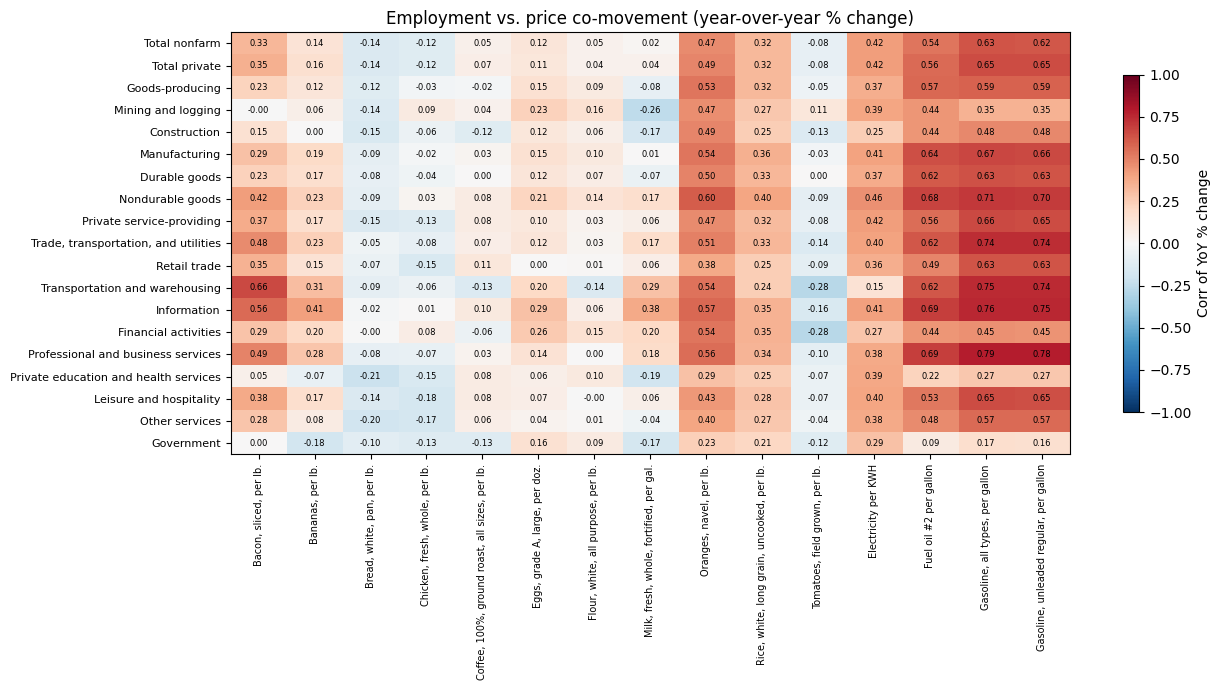

In [14]:
emp_cols   = [c for c in corr.columns if c.startswith('EMP:')]
price_cols = [c for c in corr.columns if c.startswith('PRICE:')]
cross = corr.loc[emp_cols, price_cols]

fig, ax = plt.subplots(figsize=(13, 7))
im = ax.imshow(cross.values, vmin=-1, vmax=1, cmap='RdBu_r', aspect='auto')

ax.set_xticks(range(len(price_cols)))
ax.set_xticklabels([c.replace('PRICE: ', '') for c in cross.columns], rotation=90, fontsize=7)
ax.set_yticks(range(len(emp_cols)))
ax.set_yticklabels([c.replace('EMP: ', '') for c in cross.index], fontsize=8)

for i in range(cross.shape[0]):
    for j in range(cross.shape[1]):
        ax.text(j, i, f"{cross.values[i, j]:.2f}", ha='center', va='center', fontsize=6)

fig.colorbar(im, label='Corr of YoY % change', shrink=0.8)
ax.set_title('Employment vs. price co-movement (year-over-year % change)')
plt.tight_layout()
plt.show()

### Explanation   
I ran the correlation on year-over-year percent change instead of the raw numbers because employment and prices both trend upward over time, and anything that drifts up will correlate near 1.0 with anything else that drifts up, even when they have nothing to do with each other. That would give me a heatmap that's basically all red and tells me nothing except "stuff went up since 2016," which I already knew. Converting to year-over-year growth first strips out that shared trend, so the question becomes whether the two things actually accelerate together rather than just both rising. Using a 12 month change also cancels out seasonality, since each month gets compared to the same month a year earlier.   
### Inferance   
The clearest take away is that there is strong correlation between a rise in energy prices, fuel and oil, and an increase in hiring. This does not mean that rising fuel prices causes jobs to be created. I believe it is more along the lines of increase fuel demand and increase in hiring are both commonalities in a hot economy. When there is a change in the supply/demand ratio there will be a shift in price either up or down. So if demand goes up it is assumed price will also increase. 

In [15]:
mcols = month_columns(inflation_df)   # both frames share these months

# price side: index every item to Jan 2016=100, average into one basket 
prices = inflation_df.set_index('label')[mcols].apply(pd.to_numeric, errors='coerce')
price_idx = prices.div(prices['Jan 2016'], axis=0) * 100   # each item -> 100 at base
price_basket = price_idx.mean(axis=0)                       # one number per month

# jobs side: Total nonfarm, indexed to 100 
emp_row = top_level_s.loc[top_level_s['CES Industry Title'] == 'Total nonfarm', mcols]
emp_series = emp_row.iloc[0].astype(float)
emp_idx = emp_series / emp_series['Jan 2016'] * 100

#  stress: equal-weight average of the two indexed series 
composite = pd.DataFrame({'price_basket': price_basket, 'employment': emp_idx})
composite.index = pd.to_datetime(composite.index, format='%b %Y')
composite['stress_index'] = composite['price_basket'] - (composite['employment'] - 100)
composite = composite.dropna().round(2)

composite.head()

,price_basket,employment,stress_index
2016-01-01,100.00,100.00,100.00
2016-02-01,97.24,100.14,97.10
2016-03-01,97.03,100.32,96.72
2016-04-01,97.36,100.45,96.91
2016-05-01,97.86,100.48,97.38


## Below imported from Gabriella regional_index 

In [16]:
regional_index = pd.read_csv('regional_index.csv')
regional_index.head()

,Region,2016-01-31,2016-02-29,2016-03-31,2016-04-30,2016-05-31,2016-06-30,2016-07-31,2016-08-31,2016-09-30,...,2025-07-31,2025-08-31,2025-09-30,2025-10-31,2025-11-30,2025-12-31,2026-01-31,2026-02-28,2026-03-31,2026-04-30
0,Midwest,100.0,100.296780,101.220051,101.951198,100.528540,100.912657,101.274725,101.397322,101.391752,...,139.138089,139.317244,139.738550,140.003761,140.221043,139.954254,139.200832,139.152274,138.703749,137.863955
1,Northeast,100.0,100.546530,101.155061,102.319640,99.979672,100.517765,100.661929,101.216577,101.096886,...,145.624589,145.437447,145.613733,145.477619,145.366830,144.947664,143.242757,142.826889,145.017166,141.329897
2,South,100.0,100.160665,100.535430,100.639275,100.793034,101.175856,101.241697,101.351269,101.407259,...,148.786478,149.152378,148.793509,148.171795,147.887493,147.407258,147.061664,147.888394,147.892160,147.600454
3,West,100.0,100.449491,101.221705,102.862957,103.688335,104.412995,105.045175,105.338023,105.499870,...,156.858951,157.288752,157.550838,157.156071,156.905344,155.611417,156.110318,156.856312,157.719954,156.316990


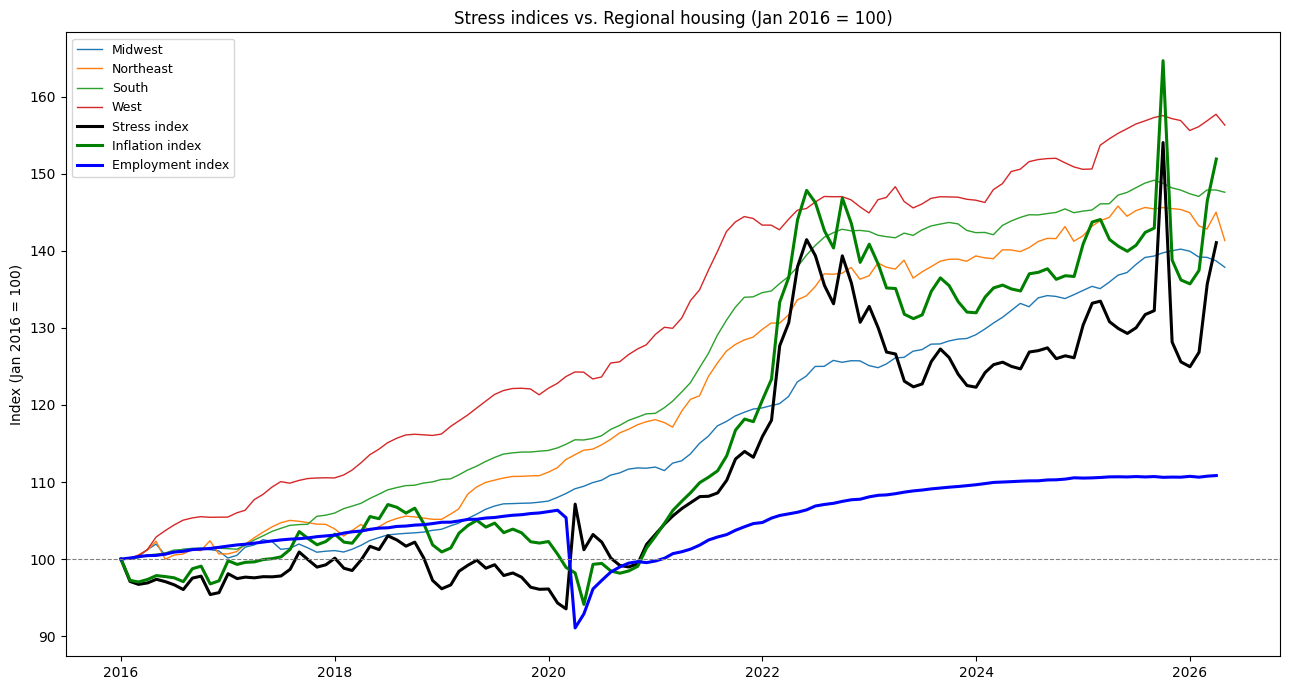

In [17]:
comp = composite.copy()
comp.index = pd.to_datetime(comp.index)

#  regional housing: Region column + monthly columns -> transpose 
reg = regional_index.set_index('Region').T
reg.index = pd.to_datetime(reg.index)

fig, ax = plt.subplots(figsize=(13, 7))

# four regional housing lines — thin, default colors
for region in reg.columns:
    ax.plot(reg.index, reg[region], lw=1.0, label=region)

# the three composite-frame lines — bold, with the labels from gabriella legend
ax.plot(comp.index, comp['stress_index'], color='black', lw=2.2, label='Stress index')
ax.plot(comp.index, comp['price_basket'],    color='green', lw=2.2, label='Inflation index')
ax.plot(comp.index, comp['employment'],      color='blue',  lw=2.2, label='Employment index')

ax.axhline(100, color='gray', lw=0.8, ls='--')   # Jan 2016 = 100 baseline
ax.set(title='Stress indices vs. Regional housing (Jan 2016 = 100)',
       ylabel='Index (Jan 2016 = 100)')
ax.legend(loc='upper left', fontsize=9)

plt.tight_layout(); plt.show()